week 4


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Load dataset
austin_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv")
austin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city                            15171 non-null  object 
 1   zipcode                         15171 non-null  int64  
 2   propertyTaxRate                 15171 non-null  float64
 3   garageSpaces                    15171 non-null  int64  
 4   hasAssociation                  15171 non-null  bool   
 5   hasCooling                      15171 non-null  bool   
 6   hasHeating                      15171 non-null  bool   
 7   hasSpa                          15171 non-null  bool   
 8   hasView                         15171 non-null  bool   
 9   parkingSpaces                   15171 non-null  int64  
 10  yearBuilt                       15171 non-null  int64  
 11  latestPrice                     15171 non-null  float64
 12  numPriceChanges                 

### Austin dataset

Confusion Matrix:
 [[1314  220]
 [ 323 1178]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83      1534
           1       0.84      0.78      0.81      1501

    accuracy                           0.82      3035
   macro avg       0.82      0.82      0.82      3035
weighted avg       0.82      0.82      0.82      3035



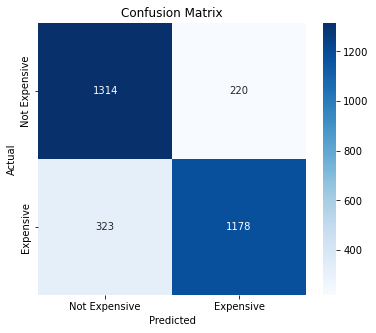

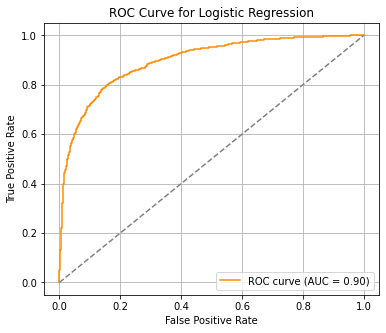

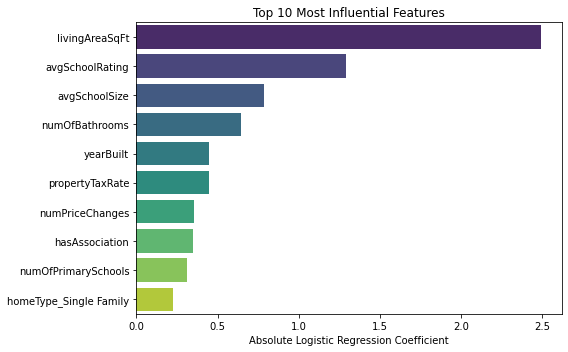

In [14]:

# Create binary target: 1 if above median price, else 0
median_price = austin_df['latestPrice'].median()
austin_df['expensive'] = (austin_df['latestPrice'] > median_price).astype(int)

# Drop non-numeric or non-predictive features
X = austin_df.drop(columns=['city', 'zipcode', 'latest_saledate', 'latestPrice', 'expensive'])
y = austin_df['expensive']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Predict
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# Evaluation
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("\nClassification Report:\n", report)

# Confusion Matrix plot
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Expensive", "Expensive"],
            yticklabels=["Not Expensive", "Expensive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve plot
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Coefficient Importance plot
coefficients = pd.Series(logreg.coef_[0], index=X.columns)
top_features = coefficients.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 10 Most Influential Features")
plt.xlabel("Absolute Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

In this analysis, I built a logistic regression model to predict whether homes in Austin are expensive based on various features like size, amenities, and school quality. After preprocessing the data and applying feature scaling, the model achieved an accuracy of 82% and an AUC score of 0.90, indicating strong predictive performance. Also found out what are the most important features. The confusion matrix and ROC curve confirmed the model's ability to distinguish between expensive and non-expensive homes effectively. This serves as a solid baseline for future comparison with more complex models. 

### Airbnb dataset

In [18]:
# Load Airbnb dataset
airbnb_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/listings_cleaned.csv")
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9697 entries, 0 to 9696
Data columns (total 69 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            9697 non-null   int64  
 1   last_scraped                                  9697 non-null   object 
 2   name                                          9697 non-null   object 
 3   host_id                                       9697 non-null   int64  
 4   host_name                                     9697 non-null   object 
 5   host_since                                    9697 non-null   object 
 6   host_location                                 9697 non-null   object 
 7   host_response_time                            9697 non-null   object 
 8   host_response_rate                            9697 non-null   object 
 9   host_acceptance_rate                          9697 non-null   o

Confusion Matrix:
 [[805 190]
 [218 727]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80       995
           1       0.79      0.77      0.78       945

    accuracy                           0.79      1940
   macro avg       0.79      0.79      0.79      1940
weighted avg       0.79      0.79      0.79      1940



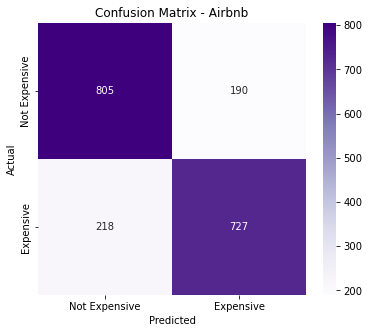

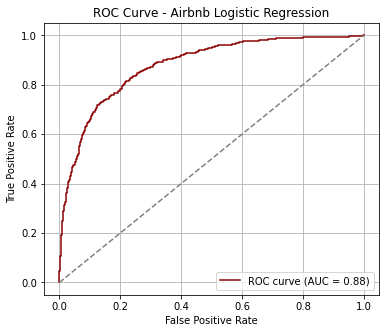

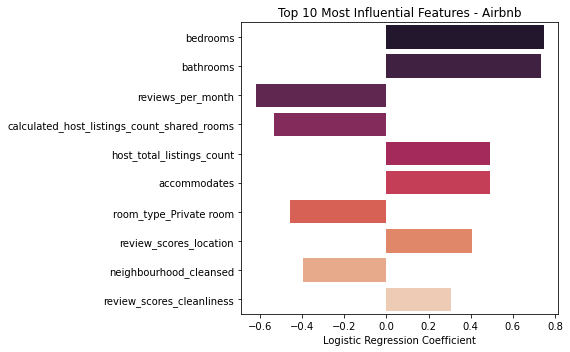

In [17]:
# Create binary target: 1 if above median price, else 0
median_price = airbnb_df['price'].median()
airbnb_df['expensive'] = (airbnb_df['price'] > median_price).astype(int)

# Drop non-numeric or non-predictive columns (adjust as needed)
X = airbnb_df.drop(columns=[
    'name', 'id', 'host_id', 'host_name', 'host_since', 'host_location',
    'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'neighbourhood', 'host_neighbourhood', 'last_scraped',
    'calendar_last_scraped', 'first_review', 'last_review', 'price', 'expensive'
])
y = airbnb_df['expensive']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Predictions
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("\nClassification Report:\n", report)

# --- Confusion Matrix Plot ---
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Not Expensive", "Expensive"],
            yticklabels=["Not Expensive", "Expensive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Airbnb")
plt.show()

# --- ROC Curve Plot ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkred', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Airbnb Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# --- Feature Importance ---
coefficients = pd.Series(logreg.coef_[0], index=X.columns)
top_features = coefficients.sort_values(key=abs, ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette="rocket")
plt.title("Top 10 Most Influential Features - Airbnb")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()